In [1]:
from facenet_pytorch import InceptionResnetV1, MTCNN
from torchvision.transforms.functional import to_pil_image, pil_to_tensor
import torch
import os
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import numpy as np
from utils import extract_face_embedding

/home/wiktor/Doktorat/SD/S2/ML_DL/facenet_gradcam/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def extract_face_embedding(resnet, path, tolist=True, mtcnn=None):
    # try:
    img = Image.open(path)
    print(img.size)
    face = mtcnn(img)

    face_to_plot  = (face + 1) / 2
    plt.figure(figsize=(10, 10))
    plt.subplot(221)
    plt.imshow(img)

    plt.subplot(222)
    plt.imshow(to_pil_image(face_to_plot))

    plt.subplot(223)
    plt.hist(pil_to_tensor(img)[0, :, :].flatten(), bins=64, alpha=0.3, color="red")
    plt.hist(pil_to_tensor(img)[1, :, :].flatten(), bins=64, alpha=0.3, color="green")
    plt.hist(pil_to_tensor(img)[2, :, :].flatten(), bins=64, alpha=0.3, color="blue")
    plt.grid(alpha=0.3)

    plt.subplot(224)
    plt.hist(face_to_plot[0, :, :].flatten(), bins=64, alpha=0.3, color="red")
    plt.hist(face_to_plot[1, :, :].flatten(), bins=64, alpha=0.3, color="green")
    plt.hist(face_to_plot[2, :, :].flatten(), bins=64, alpha=0.3, color="blue")
    plt.grid(alpha=0.3)



    if face is None:
        print(f"No face detected: {path}")
        return None

    face = face.unsqueeze(0).to('cuda')

    with torch.no_grad():
        embedding = resnet(face)

    embedding = embedding / embedding.norm(dim=1, keepdim=True)

    if tolist:
        return embedding.squeeze().cpu().tolist()
    else:
        return embedding.squeeze()

    # except Exception as e:
    #     print(f"Error processing {path}: {e}")
    #     return None


In [3]:
resnet = InceptionResnetV1(pretrained="vggface2", device=torch.device("cuda")).eval()
mtcnn = MTCNN(image_size=160, thresholds=[0.9, 0.9, 0.9], device=torch.device("cuda"))

In [4]:
face_1_path = "/home/wiktor/Doktorat/repositories/mavceleb_baseline/dataset/mavceleb_v1_train/faces/id0001/English/HpzYIwAaNlE/0002300.jpg"

(224, 224)


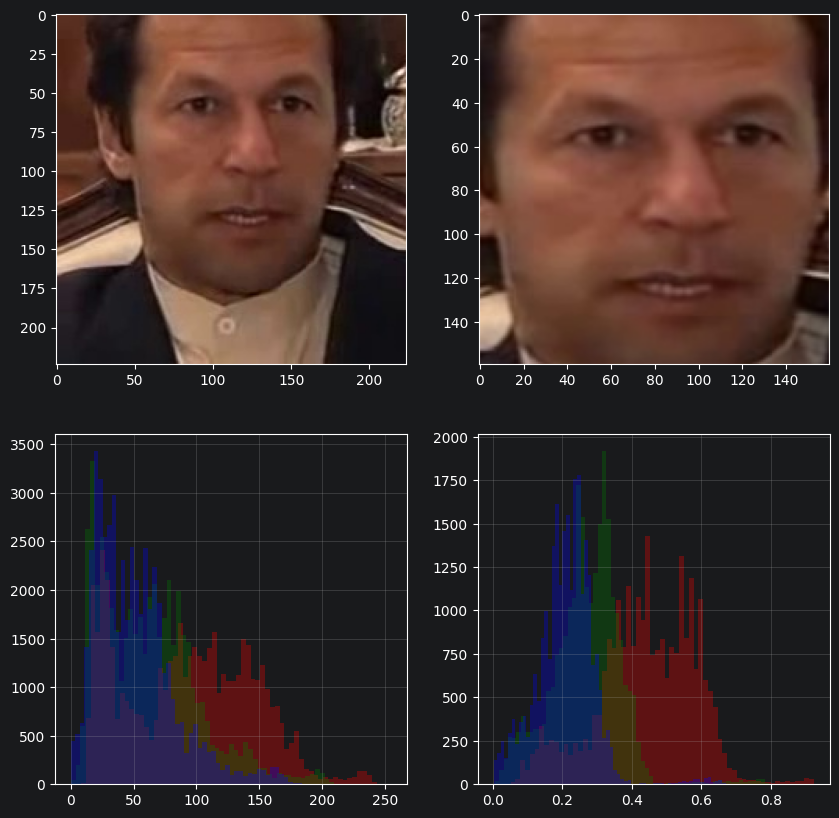

In [5]:
emb = extract_face_embedding(resnet, face_1_path, tolist=False, mtcnn=mtcnn)

In [23]:
print(emb.shape)

torch.Size([512])
